In [1]:
import pandas as pd
from datetime import datetime
from collections import defaultdict
import math

In [2]:
def calculate_growth_factor(number_of_fy: int, df: pd.DataFrame):
    """
    Calculate growth factor as average of last 3 financial years YoY growth using .pct_change().
    Expects columns 'Date' and 'Quantity' in df.
    """
    return 1 + 0.3

def generate_forecasts(df: pd.DataFrame, train_from_date: str = '2021-09-01'):
    df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce').fillna(0)

    df = df[df['Date'] >= pd.Timestamp(train_from_date)]

    # Group by date + branch and sum quantities
    grouped = (
        df.groupby(['Date', 'Branch'])['Quantity']
        .sum()
        .reset_index()
        .sort_values('Date')
    )

    # Determine FY start
    now = datetime.now()
    current_year = now.year
    current_month = now.month - 1
    fy_start = datetime(current_year, 4, 1)
    if current_month < 3:
        fy_start = datetime(current_year - 1, 4, 1)

    branches = grouped['Branch'].unique()

    for branch in branches:
        branch_data = grouped[grouped['Branch'] == branch].copy()
        if branch_data.empty:
            continue

        # Aggregate by month
        branch_data['year'] = branch_data['Date'].dt.year
        branch_data['month'] = branch_data['Date'].dt.month
        monthly = (
            branch_data.groupby(['year', 'month'])['Quantity']
            .sum()
            .reset_index()
        )
        monthly['Date'] = pd.to_datetime(
            monthly[['year', 'month']].assign(day=1)
        )
        monthly = monthly.sort_values('Date')

        if monthly.empty:
            continue

        last_date = monthly['Date'].max()
        monthly_before_fy = monthly[monthly['Date'] < fy_start]

        # --- Compute Seasonal Indices ---
        monthly_by_month = (
            monthly.groupby('month')['Quantity']
            .apply(list)
            .to_dict()
        )

        seasonal_indices = {
            month: sum(vals) / len(vals)
            for month, vals in monthly_by_month.items()
        }
        overall_avg = sum(seasonal_indices.values()) / len(seasonal_indices)
        seasonal_indices = {
            m: (v / overall_avg if overall_avg > 0 else 1)
            for m, v in seasonal_indices.items()
        }

        # --- Trend averages ---
        recent_monthly = monthly.tail(12)
        avg_recent_qty = recent_monthly['Quantity'].mean(
        ) if not recent_monthly.empty else 0

        fy_recent = monthly_before_fy.tail(12)
        avg_fy_recent_qty = fy_recent['Quantity'].mean(
        ) if not fy_recent.empty else avg_recent_qty

        forecast_start = last_date + pd.DateOffset(months=1)
        print(f"Growth rate for {branch}")
        growth_rate = calculate_growth_factor(3, branch_data)
        forecast_rows = []
        for i in range(12):
            forecast_date = forecast_start + pd.DateOffset(months=i)
            month = forecast_date.month
            months_from_last = (forecast_date - last_date).days // 30 if forecast_date > last_date else 0
            growth_factor = math.pow(growth_rate, months_from_last / 12)  # 30% annual
            seasonal = seasonal_indices.get(month, 1)
            forecast_qty = avg_recent_qty * seasonal * growth_factor

            forecast_rows.append({
                "Branch": branch,
                "Date": forecast_date.strftime("%Y-%m-%d"),
                "Forecast Quantity": round(forecast_qty, 1),
            })
    return pd.DataFrame(forecast_rows)



In [3]:
main = pd.read_csv('../data/merged_filter_ingestion.csv')
main['Date'] = pd.to_datetime(main['Date'])
branch_wise_monthly = main.groupby(['Branch', main['Date'].dt.to_period(
        'M').dt.to_timestamp()]).agg({'Quantity': 'sum'}).reset_index()

In [21]:
branch_wise_weekly = main.groupby(['Branch', main['Date'].dt.to_period(
        'W').dt.to_timestamp()]).agg({'Quantity': 'sum'}).reset_index()

In [4]:
predict = generate_forecasts(main[(main['Date'] < '2024-04-01') 
                                & (main['Date'] >= '2021-04-01') 
                                & (main['Branch'] == 'MAA')])

Growth rate for MAA


/var/folders/vg/pxkxmzld5s73d47lq0mx8hyr0000gn/T/ipykernel_42264/1413005546.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce').fillna(0)


In [7]:
branch_wise_monthly[(branch_wise_monthly['Branch'] == 'MAA') 
                    & (branch_wise_monthly['Date'] >= '2024-04-01') 
                    & (branch_wise_monthly['Date'] < '2025-04-01')]['Quantity'].sum()

np.float64(177981.0)

In [8]:
predict['Forecast Quantity'].sum()

np.float64(155766.6)

In [24]:
branch_wise_weekly[(branch_wise_weekly['Branch'] == 'MAA') 
                    & (branch_wise_weekly['Date'] < '2024-04-01')].to_csv('../data/branch_wise_weekly.csv', index=False)

In [25]:
branch_wise_weekly[(branch_wise_weekly['Branch'] == 'MAA') 
                    & (branch_wise_weekly['Date'] >= '2024-04-01') 
                    & (branch_wise_weekly['Date'] < '2025-04-01')]

,Branch,Date,Quantity
895,MAA,2024-04-01,5182.0
896,MAA,2024-04-08,9961.0
897,MAA,2024-04-15,6300.0
898,MAA,2024-04-22,10835.0
899,MAA,2024-04-29,9556.0
900,MAA,2024-05-06,8164.0
901,MAA,2024-05-13,4058.0
902,MAA,2024-05-20,2393.0
903,MAA,2024-05-27,1904.0
904,MAA,2024-06-03,977.0


In [26]:
branch_wise_monthly[(branch_wise_monthly['Branch'] == 'MAA') 
                    & (branch_wise_monthly['Date'] >= '2024-04-01') 
                    & (branch_wise_monthly['Date'] < '2025-04-01')]

,Branch,Date,Quantity
207,MAA,2024-04-01,37579.0
208,MAA,2024-05-01,20774.0
209,MAA,2024-06-01,6798.0
210,MAA,2024-07-01,5821.0
211,MAA,2024-08-01,7930.0
212,MAA,2024-09-01,10121.0
213,MAA,2024-10-01,7880.0
214,MAA,2024-11-01,6018.0
215,MAA,2024-12-01,27021.0
216,MAA,2025-01-01,13297.0


/var/folders/vg/pxkxmzld5s73d47lq0mx8hyr0000gn/T/ipykernel_42264/1055768447.py:11: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(predict['Date'], predict['Forecast Quantity'], label='Forecast Quantity', marker='x')


ConversionError: Failed to convert value(s) to axis units: array(['2024-04-01T00:00:00.000000000', '2024-05-01T00:00:00.000000000',
       '2024-06-01T00:00:00.000000000', '2024-07-01T00:00:00.000000000',
       '2024-08-01T00:00:00.000000000', '2024-09-01T00:00:00.000000000',
       '2024-10-01T00:00:00.000000000', '2024-11-01T00:00:00.000000000',
       '2024-12-01T00:00:00.000000000', '2025-01-01T00:00:00.000000000',
       '2025-02-01T00:00:00.000000000', '2025-03-01T00:00:00.000000000'],
      dtype='datetime64[ns]')

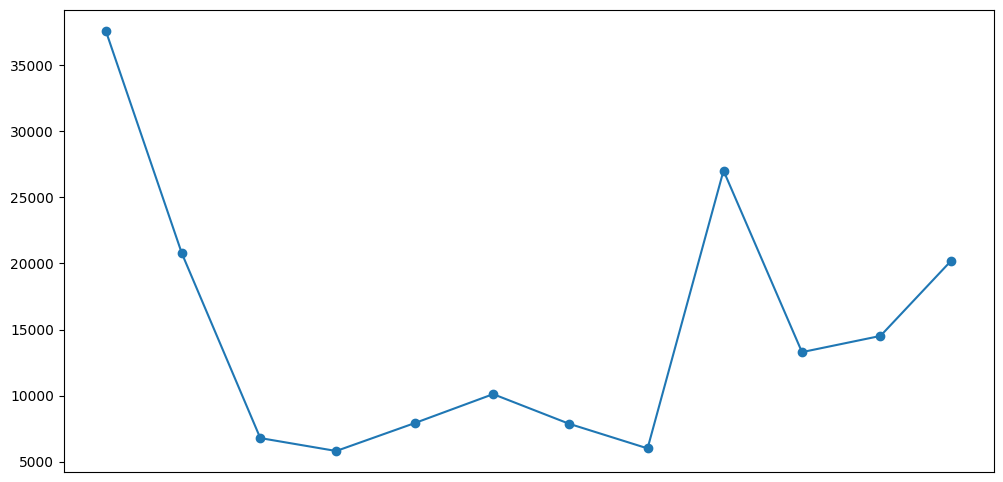

In [9]:
import matplotlib.pyplot as plt

# Select months for plotting: forecast period (Apr 2024 to Mar 2025)
forecast_start = predict['Date'].min()
forecast_end = predict['Date'].max()
mask = (branch_wise_monthly['Date'] >= forecast_start) & (branch_wise_monthly['Date'] <= forecast_end) & (branch_wise_monthly['Branch'] == 'MAA')
actual = branch_wise_monthly.loc[mask, ['Date', 'Quantity']].sort_values('Date')

plt.figure(figsize=(12, 6))
plt.plot(actual['Date'], actual['Quantity'], label='Actual Quantity', marker='o')
plt.plot(predict['Date'], predict['Forecast Quantity'], label='Forecast Quantity', marker='x')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.title('Actual vs Forecast Quantity (MAA Branch)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [102]:
def get_financial_year(dt):
    if pd.isnull(dt):
        return None
    return dt.year + 1 if dt.month >= 4 else dt.year

def new_calculate_growth_factor(df):
    df['FinancialYear'] = df['Date'].apply(get_financial_year)
    fy_branch_summary = df.groupby(['Branch', 'FinancialYear'], as_index=False)['Quantity'].sum()
    fy_branch_summary = fy_branch_summary.sort_values(['Branch', 'FinancialYear'])
    fy_branch_summary['YoY_Growth'] = fy_branch_summary.groupby('Branch')['Quantity'].pct_change()

    last_3_yoy = fy_branch_summary['YoY_Growth'].dropna()[-3:] if len(fy_branch_summary['YoY_Growth'].dropna()) >= 3 else fy_branch_summary['YoY_Growth'].dropna()

    if last_3_yoy.empty:
        return 1.25  # Fallback
    print(fy_branch_summary)
    avg_growth_percent = last_3_yoy.mean()
    return 1 + avg_growth_percent
    

In [104]:
new_calculate_growth_factor(main[(main['Date'] < '2024-04-01') 
                                & (main['Date'] >= '2021-04-01') 
                                & (main['Branch'] == 'BLR')])

  Branch  FinancialYear  Quantity  YoY_Growth
0    BLR           2022   25276.5         NaN
1    BLR           2023   29679.0    0.174174
2    BLR           2024   38130.0    0.284747


/var/folders/vg/pxkxmzld5s73d47lq0mx8hyr0000gn/T/ipykernel_65567/2338959817.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['FinancialYear'] = df['Date'].apply(get_financial_year)


np.float64(1.2294602151033387)

In [ ]:
# Calculate Growth Rate for each Financial Year, cumulatively, and per branch basis

# Make sure 'Date' is datetime and compute Financial Year
main['Date'] = pd.to_datetime(main['Date'], errors='coerce')



main['FinancialYear'] = main['Date'].apply(get_financial_year)

# Group by Branch and Financial Year and sum the Quantity
fy_branch_summary = main.groupby(['Branch', 'FinancialYear'], as_index=False)['Quantity'].sum()

# Sort values for growth calculations
fy_branch_summary = fy_branch_summary.sort_values(['Branch', 'FinancialYear'])

# Calculate Year-over-Year (YoY) Growth per branch
fy_branch_summary['YoY_Growth'] = fy_branch_summary.groupby('Branch')['Quantity'].pct_change() * 100

# Calculate Cumulative Growth per branch since first year
# def calc_cumulative_growth(x):
    # return (x / x.iloc[0] - 1) * 100

# fy_branch_summary['Cumulative_Growth'] = fy_branch_summary.groupby('Branch')['Quantity'].transform(calc_cumulative_growth)

# # All branches combined growth rates
# fy_total = main.groupby(['FinancialYear'], as_index=False)['Quantity'].sum().sort_values('FinancialYear')
# fy_total['YoY_Growth'] = fy_total['Quantity'].pct_change() * 100
# fy_total['Cumulative_Growth'] = (fy_total['Quantity'] / fy_total['Quantity'].iloc[0] - 1) * 100

# Display results
print("=== Per Branch Financial Year Growth ===")
print(fy_branch_summary)
# print("\n=== All Branches Financial Year Growth ===")
# print(fy_total)



=== Per Branch Financial Year Growth ===
   Branch  FinancialYear  Quantity  YoY_Growth
0     BLR           2020   22899.5         NaN
1     BLR           2021   16823.5  -26.533330
2     BLR           2022   25276.5   50.245193
3     BLR           2023   29679.0   17.417364
4     BLR           2024   38130.0   28.474679
5     BLR           2025   51392.0   34.781012
6     BLR           2026    7709.0  -84.999611
7     COK           2020   17301.5         NaN
8     COK           2021   14837.5  -14.241540
9     COK           2022   20007.0   34.840775
10    COK           2023   20934.5    4.635877
11    COK           2024   43639.5  108.457331
12    COK           2025   67703.0   55.141558
13    COK           2026   12251.0  -81.904790
14    MAA           2020   83443.0         NaN
15    MAA           2021   68181.0  -18.290330
16    MAA           2022   85770.5   25.798243
17    MAA           2023  104816.5   22.205770
18    MAA           2024  134713.5   28.523181
19    MAA          

In [51]:
# Create a complete set of (Branch, Month) pairs to ensure all 12 months are included for each branch
main['Month'] = main['Date'].dt.month
months = range(1, 13)
branches = main['Branch'].unique()

import itertools
branch_month_pairs = pd.DataFrame(list(itertools.product(branches, months)), columns=['Branch', 'Month'])

# Group by Branch and Month: total sales for each branch in each month in the data
monthly_sales = main.groupby(['Branch', 'Month'])['Quantity'].sum().reset_index()

# Merge to ensure all branches have all 12 months (missing months get NaN, fill with 0)
branch_month_complete = pd.merge(branch_month_pairs, monthly_sales, on=['Branch', 'Month'], how='left').fillna(0)

# Compute number of years in the dataset for correct averages
num_years = main['Date'].dt.year.nunique()

# Compute average monthly sales for each branch for each calendar month (across years)
branch_month_complete['Avg_Monthly_Sales'] = branch_month_complete['Quantity'] / num_years

# For each branch, order months by average monthly sales (high to low)
print("=== Average Monthly Sales for Each Branch (Months ordered high to low) ===")
for branch in branches:
    branch_data = branch_month_complete[branch_month_complete['Branch'] == branch][['Month', 'Avg_Monthly_Sales']]
    branch_data_sorted = branch_data.sort_values('Avg_Monthly_Sales', ascending=False)
    print(f"\nBranch: {branch}")
    print(branch_data_sorted[['Month', 'Avg_Monthly_Sales']].to_string(index=False))

# Combined average monthly sales for all branches together, for each month
total_monthly = main.groupby('Month')['Quantity'].sum().reindex(months, fill_value=0)
combined_avg_monthly = (total_monthly / num_years).reset_index()
combined_avg_monthly.columns = ['Month', 'Avg_Monthly_Sales']

# Order months high to low for combined values
combined_sorted = combined_avg_monthly.sort_values('Avg_Monthly_Sales', ascending=False)

print("\n=== Combined Average Monthly Sales (All Branches, months ordered high to low) ===")
print(combined_sorted[['Month', 'Avg_Monthly_Sales']].to_string(index=False))




=== Average Monthly Sales for Each Branch (Months ordered high to low) ===

Branch: COK
 Month  Avg_Monthly_Sales
     3        4965.357143
     4        4142.714286
    12        3289.357143
     2        3169.714286
     5        2224.285714
     8        1946.642857
     9        1858.214286
     1        1642.428571
    11        1477.571429
     6        1248.214286
     7        1155.928571
    10         975.857143

Branch: MAA
 Month  Avg_Monthly_Sales
     4       19200.642857
    12       12939.214286
     3       11288.928571
     5       10956.571429
     2        9454.857143
     1        6178.285714
     6        6140.571429
     9        6055.285714
     8        4654.714286
    10        4402.214286
     7        4015.428571
    11        3762.071429

Branch: SBD
 Month  Avg_Monthly_Sales
    12       12576.000000
     3       12214.714286
     2       10294.571429
     4        9416.642857
     1        6020.214286
     5        5360.214286
     9        3352.857143
  

In [52]:
weather_data = pd.read_csv('../data/weather_data.csv')

In [57]:
# Ensure 'Month' column exists in weather_data, extracting from 'Date' if needed
if 'Month' not in weather_data.columns:
    if 'Date' in weather_data.columns:
        weather_data = weather_data.copy()
        weather_data['Month'] = pd.to_datetime(weather_data['Date']).dt.month

print("=== Months Ordered by Avg Temp for Each Branch (Averaged Across Years) ===")
for branch in weather_data['Branch'].unique():
    branch_weather = weather_data[weather_data['Branch'] == branch]
    # Group by Month and average Avg Temp over all years
    monthly_avg_temp = branch_weather.groupby('Month', as_index=False)['Max Temp'].mean()
    sorted_monthly = monthly_avg_temp.sort_values('Max Temp', ascending=False)
    print(f"\nBranch: {branch}")
    print(sorted_monthly.to_string(index=False))

=== Months Ordered by Avg Temp for Each Branch (Averaged Across Years) ===

Branch: MAA
 Month  Max Temp
     5 40.885714
     6 40.457143
     4 39.228571
     7 37.685714
     8 37.628571
     9 36.828571
     3 36.733333
    10 34.828571
     2 33.933333
    11 32.966667
    12 32.100000
     1 31.900000

Branch: SBD
 Month  Max Temp
     5 40.142857
     4 39.571429
     6 37.857143
     3 37.833333
     2 33.833333
     9 33.142857
     7 33.000000
     8 32.857143
     1 32.000000
    11 31.166667
    10 30.857143
    12 30.000000

Branch: COK
 Month  Max Temp
     3 37.333333
     2 36.683333
     4 36.166667
     5 35.333333
     1 35.033333
    12 34.600000
    11 34.000000
     6 33.500000
     9 32.666667
     8 32.500000
     7 32.333333
    10 31.333333

Branch: BLR
 Month  Max Temp
     4 35.428571
     5 34.571429
     3 34.500000
     6 32.285714
     2 31.500000
     8 30.571429
     7 30.428571
     1 30.333333
     9 30.000000
    11 28.833333
    12 28.666667
    10

In [111]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# Ensure 'Month' and 'Year' columns exist in main DataFrame
if 'Month' not in main.columns:
    if 'Date' in main.columns:
        main = main.copy()
        main['Month'] = pd.to_datetime(main['Date']).dt.month
    else:
        raise KeyError("Neither 'Month' nor 'Date' found in main DataFrame.")

if 'Year' not in main.columns:
    if 'Date' in main.columns:
        main['Year'] = pd.to_datetime(main['Date']).dt.year
    else:
        raise KeyError("Neither 'Year' nor 'Date' found in main DataFrame.")

# Ensure 'Month' and 'Year' columns exist in weather_data DataFrame
if 'Month' not in weather_data.columns:
    if 'Date' in weather_data.columns:
        weather_data = weather_data.copy()
        weather_data['Month'] = pd.to_datetime(weather_data['Date']).dt.month

if 'Year' not in weather_data.columns:
    if 'Date' in weather_data.columns:
        weather_data['Year'] = pd.to_datetime(weather_data['Date']).dt.year

# Columns from weather_data apart from date/branch/month/year
weather_numeric_cols = [
    col for col in weather_data.columns if col not in ['Month', 'Branch', 'Date', 'Year']
]

# Prepare sales per branch, per year, per month (sum for each month in each year)
monthly_sales = main.groupby(['Branch', 'Year', 'Month'], as_index=False)['Quantity'].sum()

correlation_results = []

for branch in weather_data['Branch'].unique():
    # Get data for this branch
    branch_weather = weather_data[weather_data['Branch'] == branch]
    branch_sales = monthly_sales[monthly_sales['Branch'] == branch][['Year', 'Month', 'Quantity']]

    # Merge weather and sales on Year & Month
    merged = pd.merge(
        branch_weather, branch_sales,
        on=['Year', 'Month'],
        how='inner'
    ).sort_values(['Year', 'Month'])

    # Add a single datetime index for continuous plotting
    if 'Date' in branch_weather.columns:
        merged = merged.sort_values('Date')
        x_axis = pd.to_datetime(merged['Date'])
    else:
        # Fallback: Make a pseudo-date (first of month)
        merged = merged.sort_values(['Year', 'Month'])
        x_axis = pd.to_datetime(merged['Year'].astype(str) + '-' + merged['Month'].astype(str).str.zfill(2) + '-01')

    for col in weather_numeric_cols:
        fig = make_subplots(specs=[[{"secondary_y": True}]])

        fig.add_trace(
            go.Scatter(x=x_axis, y=merged['Quantity'], mode='lines+markers', name='Sales Quantity', line=dict(color='royalblue')),
            secondary_y=False
        )
        fig.add_trace(
            go.Scatter(x=x_axis, y=merged[col], mode='lines+markers', name=col, line=dict(color='orange')),
            secondary_y=True
        )

        fig.update_layout(
            title=f"Branch: {branch} — Sales and {col} vs Time (Continuous)",
            xaxis_title="Date",
            legend=dict(x=1.04, y=1, bordercolor="Black"),
            width=900,
            height=450
        )
        fig.update_yaxes(title_text="Sales Quantity", secondary_y=False, color='royalblue')
        fig.update_yaxes(title_text=col, secondary_y=True, color='orange')
        fig.show()

        # Calculate Pearson correlation and store results
        if merged['Quantity'].notna().sum() > 1 and merged[col].notna().sum() > 1:
            try:
                corr_score = merged[['Quantity', col]].corr(method='pearson').iloc[0, 1]
            except Exception:
                corr_score = None
        else:
            corr_score = None
        correlation_results.append({
            'Branch': branch,
            'Weather Column': col,
            'Correlation (Pearson)': corr_score
        })

# Show correlation results in a DataFrame
import pandas as pd
correlation_df = pd.DataFrame(correlation_results)
print("\n=== Correlation between Sales Quantity and Weather Columns (Pearson) per Branch ===")
print(correlation_df.to_string(index=False))









=== Correlation between Sales Quantity and Weather Columns (Pearson) per Branch ===
Branch Weather Column  Correlation (Pearson)
   MAA       Min Temp               0.159294
   MAA       Max Temp               0.100471
   MAA       Avg Temp               0.077929
   MAA   Min Humidity              -0.136092
   MAA   Max Humidity              -0.445742
   MAA   Avg Humidity              -0.022658
   MAA Min Wind Speed                    NaN
   MAA Max Wind Speed               0.076532
   MAA Avg Wind Speed               0.186435
   SBD       Min Temp              -0.350637
   SBD       Max Temp               0.104644
   SBD       Avg Temp              -0.000420
   SBD   Min Humidity              -0.554719
   SBD   Max Humidity              -0.341215
   SBD   Avg Humidity              -0.533485
   SBD Min Wind Speed               0.104641
   SBD Max Wind Speed              -0.145799
   SBD Avg Wind Speed              -0.189322
   COK       Min Temp               0.056695
   COK       Ma

In [114]:
main[(main['Branch'] == 'BLR') & (main['Star Rating'] == '3 Star') & (main['Tonnage'] == 1.5) & (main['Segment']== 'Inv')]['Item Code'].value_counts()

Item Code
RKL50UV16VAF       931
RKL50UV16V3        776
RKL50TV16V         527
RKL50UV16VA        456
RKL50UV16V         342
RKL50TV16VF        307
RKC50UV16VF        186
RKL50TV16VC        164
RKY50UV16V3        124
RKT50TV16V         117
RKY50UV16V3F        82
RKL50TV16U          70
RHT50UV16V          67
RKT50TV16VC         62
RKY50TV16V3         57
RKC50UV16V          50
RHT50TV16U          45
RKLG50UV16V3        45
RKY50UV16U2         34
RKY50UV16V2         29
RKLG50TV16V         20
RKY50UV16U3         16
RKC48UV16W          16
RKJ50UV16V           7
RKY50UV16V3A         6
RKLG50TV16VF         3
RKT50UV16V           3
RKLG50TV16U          3
RKL50UV16V3-RV       2
RKL50UV16V-RV        2
RKYG50TV16V3         1
RKL50TV16VF-RV       1
RKL50TV16VC-RV       1
RKLG50UV16V          1
RKR50UV16U           1
RHT50TV16U-RV        1
RKD50BVM-RV          1
RKL50UV16VAF-RV      1
RKL50TV16V-RV        1
Name: count, dtype: int64